In [1]:
!pip install sentence-transformers seaborn matplotlib
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import torch

In [2]:
model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "The batsman hit a massive six over the long-on boundary.", # Cricket
    "India won the world cup after a thrilling final match.", # Cricket
    "The leg-spinner struggled to find his line and length today.", # Cricket
    "Slow-cooking the mutton ensures the meat stays tender and juicy.", # Cooking
    "Sauté the onions until they are golden brown and translucent.", # Cooking
    "A pinch of saffron adds a distinct aroma to the biryani.", # Cooking
    "Multi-factor authentication is a critical layer of defense.", # Cybersecurity
    "The hacker attempted a brute-force attack on the server.", # Cybersecurity
    "Phishing emails often trick users into revealing passwords.", # Cybersecurity
    "Regular software updates help patch critical security flaws."  # Cybersecurity
]

embeddings = model.encode(sentences, convert_to_tensor=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

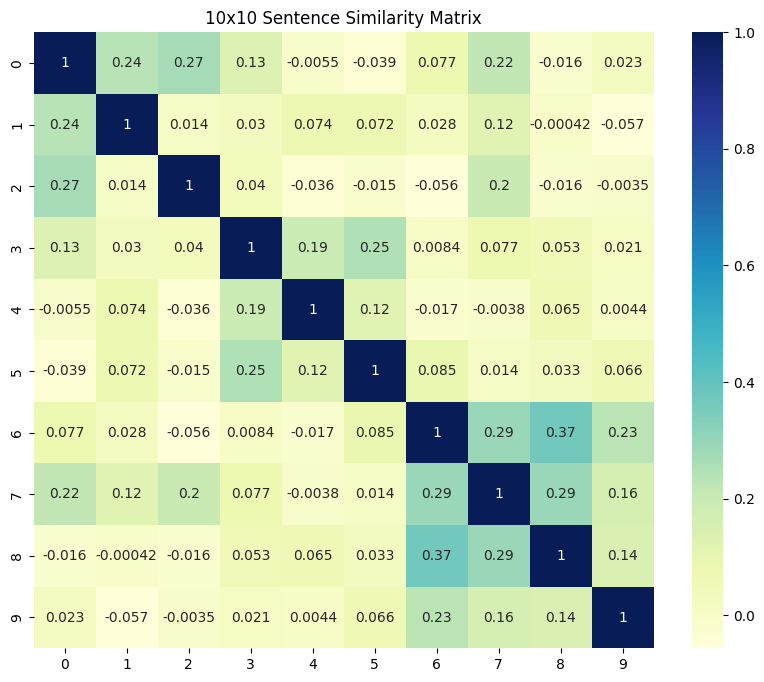

In [3]:
cosine_scores = util.cos_sim(embeddings, embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(cosine_scores.cpu().numpy(), annot=True, cmap='YlGnBu')
plt.title("10x10 Sentence Similarity Matrix")
plt.show()

In [5]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

# Find top 2 matches
hits = util.semantic_search(query_embedding, embeddings, top_k=2)

print(f"Query: {query}\n")
for hit in hits[0]:
    print(f"Match: {sentences[hit['corpus_id']]}")
    print(f"Score: {hit['score']:.4f}\n")

Query: The bowler took three wickets in one over

Match: The batsman hit a massive six over the long-on boundary.
Score: 0.5319

Match: India won the world cup after a thrilling final match.
Score: 0.3896

